# Newton's Method for Optimization and Root Finding

Newton's method is a second-order optimization algorithm that exploits curvature
information to achieve much faster convergence than first-order methods like
gradient descent.  This notebook explores Newton's method in two closely related
settings -- **minimization** and **root finding** (Newton-Raphson) -- and
investigates the practical issues that arise when using it.

**What you will learn:**

1. The Newton update rule
   $x^{k+1} = x^k - [f''(x^k)]^{-1}\,f'(x^k)$ for minimization, and the
   Newton-Raphson rule $x^{k+1} = x^k - F(x^k)/F'(x^k)$ for solving $F(x)=0$.
2. Convergence pitfalls: sensitivity to initialization, cycling, divergence,
   domain violations, and Newton fractals.
3. **Damped Newton** with backtracking line search as a practical remedy.
4. **Quadratic convergence** theory under strong convexity and Lipschitz Hessian.
5. Comparison of Newton's method with gradient descent on logistic regression
   and log-barrier problems.

In [ ]:
# If running for the first time, uncomment and run:
# !pip install numpy pandas autograd matplotlib

##Newton's Method for Minimization

Newton's method for minimization is based on the principle of iteratively finding the minimum of a function by using its second-order Taylor series expansion around a point. For a twice-differentiable function $f(x)$, the second-order Taylor expansion around a point $x_0$ is given by:

\begin{equation}
f(x) \approx f(x_0) + f'(x_0)(x - x_0) + \frac{1}{2}f''(x_0)(x - x_0)^2
\end{equation}

Minimizing this approximation leads to an update rule where the next point $x_1$ is computed as:

\begin{equation}
x_{n+1} = x_n - \frac{f'(x_n)}{f''(x_n)}
\end{equation}

This method assumes that the function's second derivative, $f''(x)$, is positive (indicating a convex function at $x_n$), which ensures that the update step moves towards a minimum.

### Example: Minimizing $f(x) =
 x* \log(x) -2 x   $

Consider the function $f(x) =   x* \log(x) -2 x   $, which we aim to minimize. The first and second derivatives of $f(x)$ are:

\begin{equation}
f'(x) =  \log (x)-1
\end{equation}

\begin{equation}
f''(x) = 1/x
\end{equation}
This is a convex function on the domain $x > 0$. The minimizer is given by $x = e$.

In the following, we plot the quadratic expansion at the newton iterates starting from $x_0 = 6$.

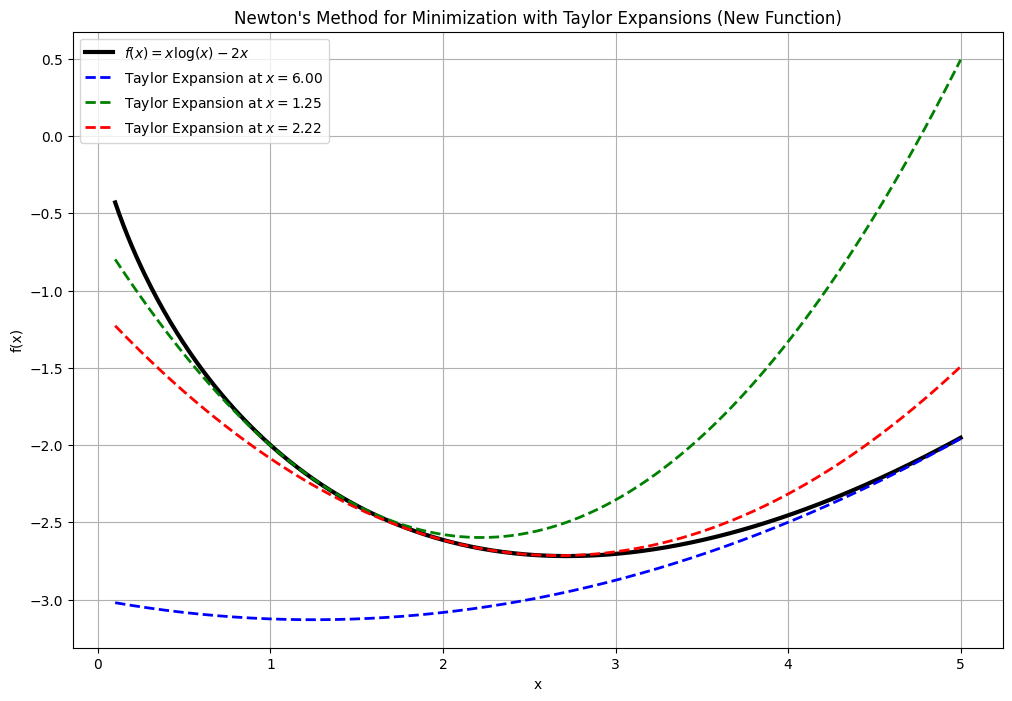

[6, 1.2494431846316703, 2.220637871211863]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Redefine the function, its first and second derivatives for the new function f(x) = -log(x) + 1
# def f_new(x):
#     return -np.log(x) + x**2

# def df_new(x):
#     return -1/x + x

# def ddf_new(x):
#     return 1/x**2 +1


# Redefine the function, its first and second derivatives for the new function f(x) = -log(x) + 1
def f_new(x):
    return x * np.log(x) - 2*x

def df_new(x):
    return np.log(x) -1

def ddf_new(x):
    return 1/x


# Redefine the second-order Taylor expansion around x0 for the new function
def taylor_expansion_new(x, x0):
    return f_new(x0) + df_new(x0) * (x - x0) + 0.5 * ddf_new(x0) * (x - x0)**2

# Redefine Newton's method step for minimization for the new function
def newton_step_new(x0):
    return x0 - df_new(x0) / ddf_new(x0)

# Reset initial point and perform 3 steps of Newton's method for the new function
x0_new = 6
iterations_new = [x0_new]

for _ in range(2):
    x0_new = newton_step_new(x0_new)
    iterations_new.append(x0_new)

# Plotting for the new function
x_new = np.linspace(0.1, 5, 400)
y_new = f_new(x_new)

plt.figure(figsize=(12, 8))

# Plot original function with thicker line
plt.plot(x_new, y_new, label='$f(x) = x \log(x)  - 2 x  $', color='black', linewidth=3)

# Plot Taylor expansions with thicker lines
colors_new = ['blue', 'green', 'red', 'purple']
for i, x0_new in enumerate(iterations_new):
    y_approx_new = taylor_expansion_new(x_new, x0_new)
    plt.plot(x_new, y_approx_new, '--', label=f'Taylor Expansion at $x = {x0_new:.2f}$', color=colors_new[i], linewidth=2)

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Newton\'s Method for Minimization with Taylor Expansions (New Function)')
plt.grid(True)
plt.show()

iterations_new # Display the iterations for reference




## Newton Raphson Method

The Newton-Raphson method is a root-finding algorithm that uses the first few terms of the Taylor series of a function to approximate roots of equations. For a function $f(x)$, assuming $x_n$ is an approximation to a root of $f(x)$, the Taylor series expansion of $f$ around $x_n$ is:


\begin{equation}
f(x) = f(x_n) + f'(x_n)(x - x_n) + \frac{f''(x_n)}{2!}(x - x_n)^2 + \cdots
\end{equation}

Ignoring higher-order terms, and solving for $x$ when $f(x) = 0$, gives the Newton-Raphson iteration formula:

\begin{equation}
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
\end{equation}

This formula is iteratively applied until a sufficiently accurate value is found. For multivariate functions, the method is extended by utilizing the Jacobian matrix of first derivatives and the Hessian matrix of second-order derivatives to find the roots of a system of equations.


## Newton-Raphson Intuition on a Univariate Function

Consider the function $f(x) = \log(x) - 1$, and let our initial guess be $x_0 = 3$. The Newton-Raphson update formula is given by:

\begin{equation}
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
\end{equation}

At $x_0 = 6$, the tangent line to $f(x)$ can be expressed as $y = f'(x_0)(x - x_0) + f(x_0)$. This line intersects the x-axis at the point $(x_1, 0)$, which serves as the next approximation to the root. The graphical demonstration shows how, starting from $x_0 = 6$, we apply the Newton-Raphson formula to find $x_1$, marking a step closer to the root of $f(x)$.

This iterative process continues, leveraging the derivative of $f$ at each step to guide us to the function's root, illustrating the power of the Newton-Raphson method for solving equations numerically.


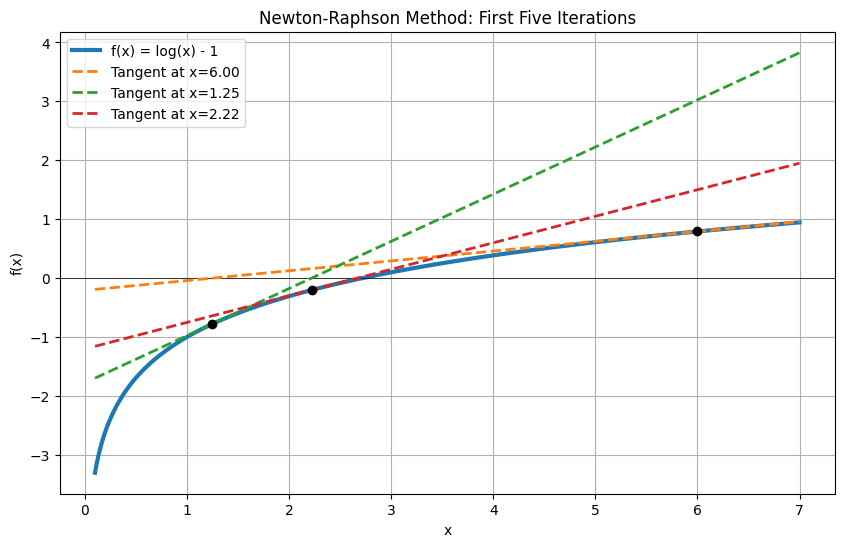

In [ ]:
# Adjust the Newton-Raphson code to plot the tangent line at the first five iterations

# Redefine the function and its derivative
def f(x):
    return np.log(x) - 1

def df(x):
    return 1/x

# Redefine Newton-Raphson iteration starting point
x0 = 6

# Plotting setup
x = np.linspace(0.1, 7, 400)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x) = log(x) - 1', linewidth=3)
plt.axhline(0, color='black', lw=0.5)

# Iterate and plot the tangent lines for the first five iterations
for i in range(3):
    m = df(x0)  # Slope of the tangent line at x0
    b = f(x0) - m * x0  # Y-intercept of the tangent line at x0
    tangent_line = lambda x: m * x + b  # Tangent line equation

    # Plot tangent line
    plt.plot(x, tangent_line(x), '--', label=f'Tangent at x={x0:.2f}', linewidth=2)

    # Plot current guess
    plt.plot(x0, f(x0), 'ko')  # Black dot for the current guess

    # Calculate next iterate
    x1 = x0 - f(x0) / df(x0)

    # Plot next iterate point on x-axis
    # plt.plot(x1, 0, 'ro')  # Red dot for the next iterate

    # Update x0 for the next iteration
    x0 = x1

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Newton-Raphson Method: First Five Iterations')
plt.grid(True)
plt.show()


#Convergence Behaviors of Newton Raphson

In general, Newton Raphson (and Newton's Method) does not always converge. It is very sensitive to the intialization point, and to whether the Jacobian is invertible or not.

# Convergence Cases

**Example** Use Newton Raphson to find square root: $f(x) = x^2 - 9$.

We consider the function $f(x) = x^2 - 9$ to demonstrate the convergence behavior of the Newton-Raphson method. This experiment highlights how different initial guesses lead to convergence to different roots of the equation.

The method was initialized from four different points: $x_0 = 5$, $x_0 = 1$, $x_0 = -1$, and $x_0 = -5$. Each initial point led to the following observations:

- Starting from $x_0 = 5$ and $x_0 = 1$, the method converges to the positive root, approximately $x \approx 3$.
- Starting from $x_0 = -1$ and $x_0 = -5$, convergence is observed towards the negative root, approximately $x \approx -3$.

Moreover, if we start from $x _0 = 0$, the method fails because $f'(x_0) = 0$ is not invertible.  


These results illustrate the significant impact of the **initial guess** on the convergence of the Newton-Raphson method. Depending on the starting point, the method may converge to either of the quadratic equation's roots.


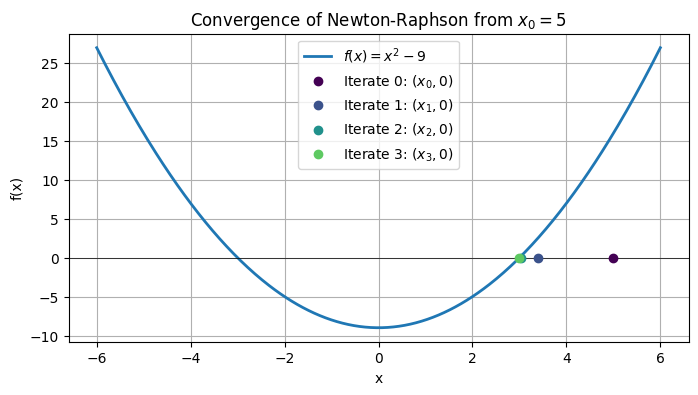

Iterates from x0 = 5: [5, 3.4, 3.023529411764706, 3.00009155413138]


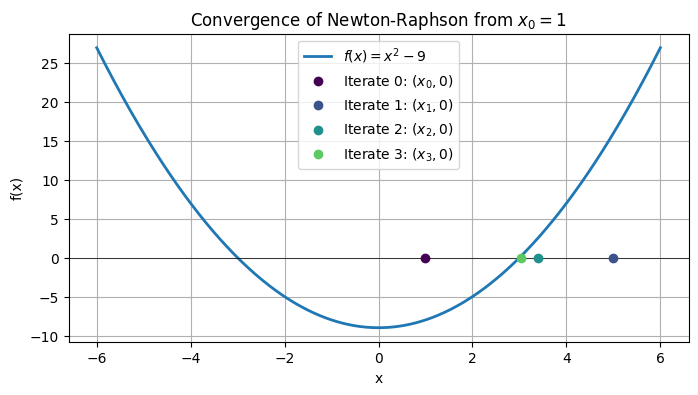

Iterates from x0 = 1: [1, 5.0, 3.4, 3.023529411764706]


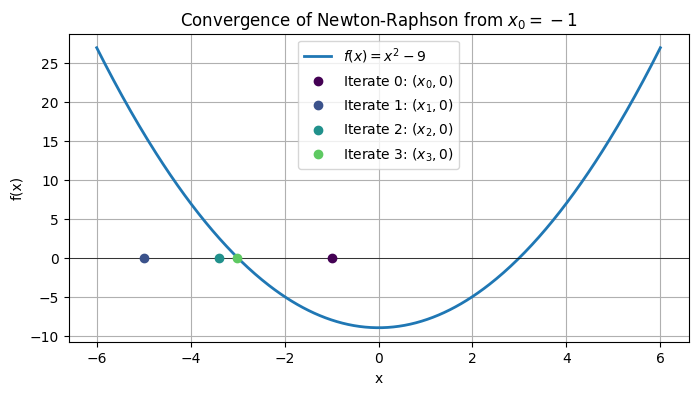

Iterates from x0 = -1: [-1, -5.0, -3.4, -3.023529411764706]


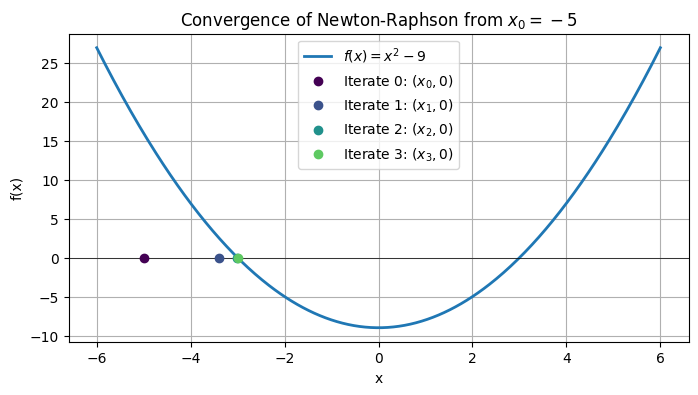

Iterates from x0 = -5: [-5, -3.4, -3.023529411764706, -3.00009155413138]


In [ ]:
# Define the function, its derivative, and the Newton-Raphson iteration function
a = 9

def f(x):
    return x**2 - a

def df(x):
    return 2*x

def newton_raphson(x0, n_iter=3):
    iterates = [x0]
    for _ in range(n_iter):
        x0 = x0 - f(x0) / df(x0)
        iterates.append(x0)
    return iterates

# Initial points
initial_points = [5, 1, -1, -5]

# Plot settings
x = np.linspace(-6, 6, 400)
y = f(x)

# Generate four plots for each initial point
for x0 in initial_points:
    iterates = newton_raphson(x0)
    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label='$f(x) = x^2 - 9$', linewidth=2)
    plt.axhline(0, color='black', lw=0.5)

    # Plot iterates
    for i, xi in enumerate(iterates):
        plt.plot(xi, 0, 'o', label=f'Iterate {i}: $(x_{i}, 0)$', color=plt.cm.viridis(i / len(iterates)))

    plt.legend()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title(f'Convergence of Newton-Raphson from $x_0 = {x0}$')
    plt.grid(True)
    plt.show()

    # Print out the iterates for each initial point
    print(f"Iterates from x0 = {x0}: {iterates}")


## Convergence is sensitive to initialization

Perhaps we think this is not a big issue. That just means that the domain is splitted into a few areas, each area consists of initialization points that converges to one root. Actually, the behavior is a bit more chaotic and **Newton Raphson is very sensitive to initialization**.

Consider the polynomial $f(x) = x^3 - 2 x^2 - 11 x + 12$. The three roots are $-3,1,4$. We initialize from five different points that are quite close.
$x_0 \in \{ 2.352875270,2.352841720, 2.352837350,  2.352836327, 2.352836323 \} $. These numbers are listed in a descending order.


    x0 = 2.352875270  x0 = 2.352841720  x0 = 2.352837350  x0 = 2.352836327  \
0           2.352875          2.352842          2.352837          2.352836   
1          -0.783264         -0.782984         -0.782948         -0.782939   
2           2.354307          2.353040          2.352875          2.352836   
3          -0.795260         -0.784639         -0.783262         -0.782941   
4           2.409935          2.360549          2.354299          2.352842   
5          -1.360911         -0.848847         -0.795193         -0.782984   
6      166461.139621          2.694168          2.409618          2.353036   
7      110974.315320     -12055.349019         -1.357026         -0.784609   
8       73983.099127      -8036.677351        436.832554          2.360415   
9       49322.288344      -5357.563020        291.450202         -0.847671   
10      32881.747840      -3571.486969        194.531767          2.687229   
11      21921.387532      -2380.769858        129.924169       -

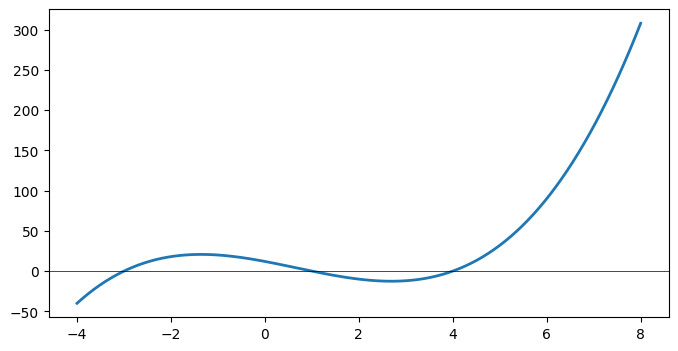

In [ ]:
import pandas as pd



# Define the function, its derivative, and the Newton-Raphson iteration function for the new polynomial
def f_poly(x):
    return x**3 - 2*x**2 - 11*x + 12

def df_poly(x):
    return 3*x**2 - 4*x - 11

def newton_raphson_poly(x0, n_iter=40):
    iterates = [x0]
    for _ in range(n_iter):
        x0 = x0 - f_poly(x0) / df_poly(x0)
        iterates.append(x0)
    return iterates

# Initial points for the new polynomial
initial_points_poly = [2.352875270, 2.352841720,  2.352837350,  2.352836327, 2.352836323]

# Plot the function and iterates for each initial point
x_poly = np.linspace(-4, 8, 400)
y_poly = f_poly(x_poly)

plt.figure(figsize=(8, 4))
plt.plot(x_poly, y_poly, label='$f(x) = x^3 - 2x^2 - 11x + 12$', linewidth=2)
plt.axhline(0, color='black', lw=0.5)

trajectories = []

for x0 in initial_points_poly:
    iterates_poly = newton_raphson_poly(x0)
    trajectories.append(iterates_poly)

    # plt.figure(figsize=(8, 4))
    # plt.plot(x_poly, y_poly, label='$f(x) = x^3 - 2x^2 - 11x + 12$', linewidth=2)
    # plt.axhline(0, color='black', lw=0.5)

    # # Plot iterates
    # for i, xi in enumerate(iterates_poly):
    #     plt.plot(xi, 0, 'o', label=f'Iterate {i}: $(x_{i}, 0)$', color=plt.cm.viridis(i / len(iterates_poly)))

    # # plt.legend()
    # plt.xlabel('x')
    # plt.ylabel('f(x)')
    # plt.title(f'Convergence from $x_0 = {x0}$')
    # plt.grid(True)
    # plt.show()

    # Output message for each initial point
    # print(f"Initialized from x_0 = {x0}, the iterates are {iterates_poly}.")



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = [f"x0 = {x0:.9f}" for x0 in initial_points_poly]

# Print the DataFrame
print(df)



##  Newton Fractal

Consider the equation $f(z) = 0$ where $f$ is a polynomial and $z$ is a complex number $a+ b\cdot i$. We can also run Newton's method and solve the equation. For example, for $f(z) = z^3 + 1 = 0$, there are three roots, $z = 1$ and two complex roots. We can try to enumerate all $z = (a,b)$ on the complex plane and plot these points in three colors, representing the three roots. Where each color means that if we initalize Newton's method from this point, we arrive at a particular solution. The image we get is a fractal. This means that, **no matter how small we perturb the initial point**, we are always able to find to different initializations $z_0$ and $z_0'$, which converge to different roots.

![Newton Fractal](https://paulbourke.net/fractals/newtonraphson/roots1.jpg)

References
- https://paulbourke.net/fractals/newtonraphson/
- https://www.3blue1brown.com/lessons/newtons-fractal
- https://scipython.com/book2/chapter-8-scipy/examples/the-newton-fractal/ (code)


In the following, let's plot the Newton Fractal for $f(z) = z^3 - 1$ and $f(z) = z^4 - 1$.

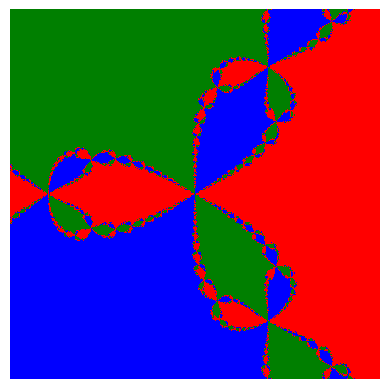

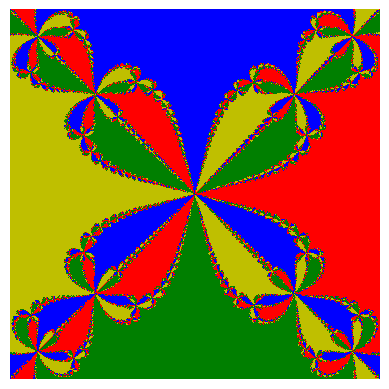

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# A list of colors to distinguish the roots.
colors = ['b', 'r', 'g', 'y']

TOL = 1.e-8

def newton(z0, f, fprime, MAX_IT=1000):
    """The Newton-Raphson method applied to f(z).

    Returns the root found, starting with an initial guess, z0, or False
    if no convergence to tolerance TOL was reached within MAX_IT iterations.

    """

    z = z0
    for i in range(MAX_IT):
        dz = f(z)/fprime(z)
        if abs(dz) < TOL:
            return z
        z -= dz
    return False

def plot_newton_fractal(f, fprime, n=200, domain=(-1, 1, -1, 1)):
    """Plot a Newton Fractal by finding the roots of f(z).

    The domain used for the fractal image is the region of the complex plane
    (xmin, xmax, ymin, ymax) where z = x + iy, discretized into n values along
    each axis.

    """

    roots = []
    m = np.zeros((n, n))

    def get_root_index(roots, r):
        """Get the index of r in the list roots.

        If r is not in roots, append it to the list.

        """

        try:
            return np.where(np.isclose(roots, r, atol=TOL))[0][0]
        except IndexError:
            roots.append(r)
            return len(roots) - 1

    xmin, xmax, ymin, ymax = domain
    for ix, x in enumerate(np.linspace(xmin, xmax, n)):
        for iy, y in enumerate(np.linspace(ymin, ymax, n)):
            z0 = x + y*1j
            r = newton(z0, f, fprime)
            if r is not False:
                ir = get_root_index(roots, r)
                m[iy, ix] = ir
    nroots = len(roots)
    if nroots > len(colors):
        # Use a "continuous" colormap if there are too many roots.
        cmap = 'hsv'
    else:
        # Use a list of colors for the colormap: one for each root.
        cmap = ListedColormap(colors[:nroots])
    plt.imshow(m, cmap=cmap, origin='lower')
    plt.axis('off')
    plt.show()

f = lambda z: z**3 - 1
fprime = lambda z: 3*z**2

plot_newton_fractal(f, fprime, n=500)


f = lambda z: z**4 - 1
fprime = lambda z: 4*z**3

plot_newton_fractal(f, fprime, n=500)

## It might have a root jumping behavior

Consider $f(x) = \sin(x)$ and we initialize from $x = 2.4 \pi$.

    x0 = 7.853981634  x0 = 7.571238295  x0 = 7.539822369  x0 = 7.508406442
0       7.853982e+00          7.571238      7.539822e+00          7.508406
1      -3.266248e+15          4.129216      4.462139e+00          4.730800
2      -3.266248e+15          2.613406      5.499043e-01         59.041175
3      -3.266248e+15          3.196890     -6.306924e-02         59.799937
4      -3.266248e+15          3.141536      8.375739e-05         59.689819
5      -3.266248e+15          3.141593     -1.958611e-13         59.690260
6      -3.266248e+15          3.141593      0.000000e+00         59.690260
7      -3.266248e+15          3.141593      0.000000e+00         59.690260
8      -3.266248e+15          3.141593      0.000000e+00         59.690260
9      -3.266248e+15          3.141593      0.000000e+00         59.690260
10     -3.266248e+15          3.141593      0.000000e+00         59.690260


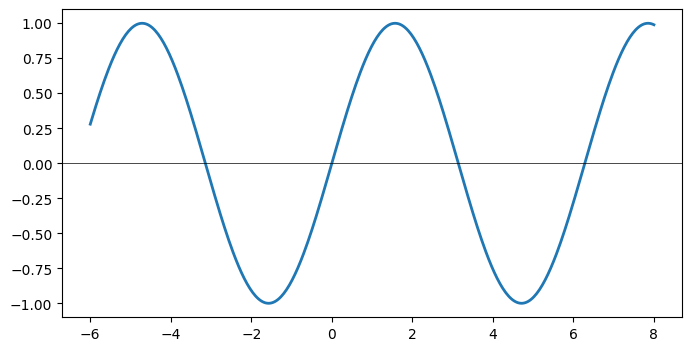

In [ ]:

def newton_raphson(x0, n_iter=10):
    iterates = [x0]
    for _ in range(n_iter):
        x0 = x0 - np.sin(x0) / np.cos(x0)
        iterates.append(x0)
    return iterates

# Initial points for the new polynomial
initial_points = [2.5 * np.pi, 2.41* np.pi, 2.4 *np.pi, 2.39 * np.pi]

# x = 2.5 pi gives F'(x) = 0.


# Plot the function and iterates for each initial point
x = np.linspace(-6, 8, 400)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$f(x) = sin(x)$', linewidth=2)
plt.axhline(0, color='black', lw=0.5)

trajectories = []

for x0 in initial_points:
    iterates = newton_raphson(x0)
    trajectories.append(iterates)



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = [f"x0 = {x0:.9f}" for x0 in initial_points]

# Print the DataFrame
print(df)


# It might cycle.

That is, let $N_{F}(x) = x - F(x) / F'(x)$ be the Newton update. We can construct examples satisfying $N_{F}( N_{F}(x) ) = x$ (And even $N_F ( N_{F}( N_{F}(x) ) )  = x$, i.e., cycle of period 3). See https://math.stackexchange.com/questions/977814/fun-with-newtons-method-infinitely-many-cycles for details.

Let's see an example with peiord 2.

    x0 = 0.000000000  x0 = 1.000000000
0                0.0               1.0
1                1.0               0.0
2                0.0               1.0
3                1.0               0.0
4                0.0               1.0
5                1.0               0.0
6                0.0               1.0
7                1.0               0.0
8                0.0               1.0
9                1.0               0.0
10               0.0               1.0


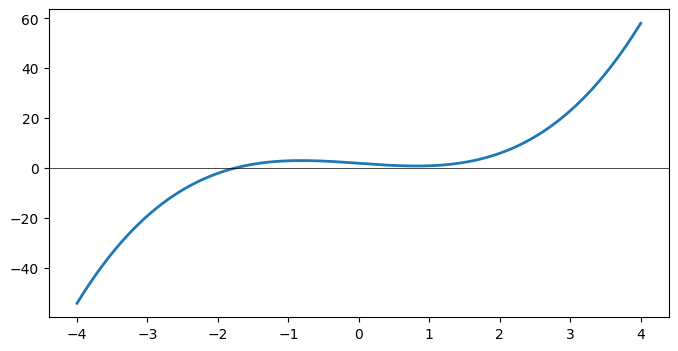

In [ ]:
# Define the function, its derivative, and the Newton-Raphson iteration function for the new polynomial
def f(x):
    return x**3 - 2*x + 2

def df(x):
    return 3*x**2 - 2


def newton_raphson(x0, n_iter=10):
    iterates = [x0]
    for _ in range(n_iter):
        x0 = x0 - f(x0) / df(x0)
        iterates.append(x0)
    return iterates

# Initial points for the new polynomial
initial_points = [0, 1]

# x = 2.5 pi gives F'(x) = 0.


# Plot the function and iterates for each initial point
x = np.linspace(-4,4, 400)
y = f(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$f(x) = x^3 - 2x + 2$', linewidth=2)
plt.axhline(0, color='black', lw=0.5)

trajectories = []

for x0 in initial_points:
    iterates = newton_raphson(x0)
    trajectories.append(iterates)



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = [f"x0 = {x0:.9f}" for x0 in initial_points]

# Print the DataFrame
print(df)


## Newton Method might fail to converge

Consider $f(x) = x^{1/3}$. The derivative is $f'(x) = 1/3 \cdot x^{-2/3}$.

Newton update is given by
$$
N(x) = x - f(X) / f'(x) = x - 3 x = -2 x.
$$
This means that $| N(x)|  >  |x| $ unless $x = 0$.

    x0 = 0.010000000  x0 = 2.000000000
0         0.01+0.00j        2.00+0.00j
1        -0.02+0.00j       -4.00+0.00j
2         0.04-0.00j        8.00-0.00j
3        -0.08+0.00j      -16.00+0.00j
4         0.16-0.00j       32.00-0.00j
5        -0.32+0.00j      -64.00+0.00j
6         0.64-0.00j        128.0-0.0j
7        -1.28+0.00j       -256.0+0.0j
8         2.56-0.00j        512.0-0.0j
9        -5.12+0.00j      -1024.0+0.0j
10       10.24-0.00j       2048.0-0.0j


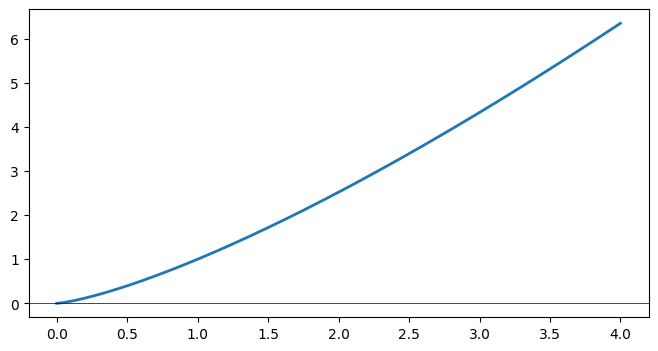

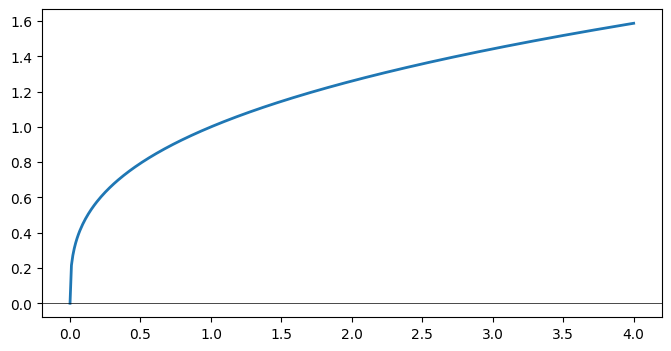

In [ ]:
# Divergent case


def f(x):
    return x ** (1/3)

def df(x):
    return 1/3 * x ** (-2/3)


def newton_raphson(x0, n_iter=10):
    iterates = [x0]
    for _ in range(n_iter):
        x0 = x0 - f(x0) / df(x0)
        iterates.append(x0)
    return iterates

# Initial points for the new polynomial
initial_points = [0.01, 2]


# Plot the function and iterates for each initial point
x = np.linspace(0,4, 400)
y = f(x)
z = x**(4/3)

plt.figure(figsize=(8, 4))
plt.plot(x, z, label='$f(x) = x^{4/3} $', linewidth=2)
plt.axhline(0, color='black', lw=0.5)


plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$f(x) = x^{1/3} $', linewidth=2)
plt.axhline(0, color='black', lw=0.5)

trajectories = []

for x0 in initial_points:
    iterates = newton_raphson(x0)
    trajectories.append(iterates)



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = [f"x0 = {x0:.9f}" for x0 in initial_points]

# Print the DataFrame
print(df)

### It is possible that some function have a natural domain such that newton methods yields an update that violates the constraint.

For example, consider minimizing $f(x) = x \log x + x$, or equivalently finding the root of $F(x) = \log x + 2$. $F'(x) = 1/x$.

Consider $x_0 = 1$. Then after one newton step, $x_1 = -1$.


<ipython-input-11-b0d7d584e705>:7: RuntimeWarning: divide by zero encountered in log
  return np.log(x) + 2
<ipython-input-11-b0d7d584e705>:4: RuntimeWarning: divide by zero encountered in log
  return np.log(x) * x + x
<ipython-input-11-b0d7d584e705>:4: RuntimeWarning: invalid value encountered in multiply
  return np.log(x) * x + x
<ipython-input-11-b0d7d584e705>:7: RuntimeWarning: invalid value encountered in log
  return np.log(x) + 2


   x0 = 0.010000000  x0 = 1.000000000  x0 = 3.000000000
0          0.010000               1.0          3.000000
1          0.036052              -1.0         -6.295837
2          0.083741               NaN               NaN
3          0.123939               NaN               NaN
4          0.134841               NaN               NaN
5          0.135334               NaN               NaN


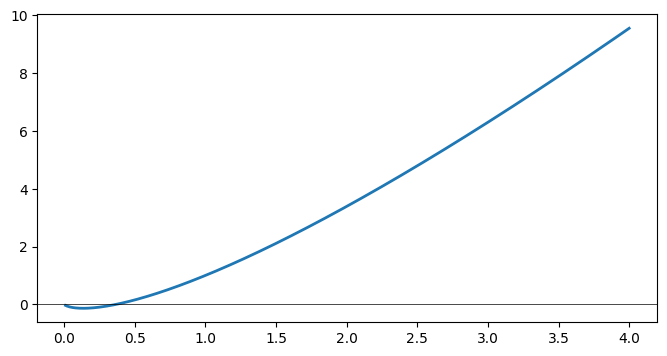

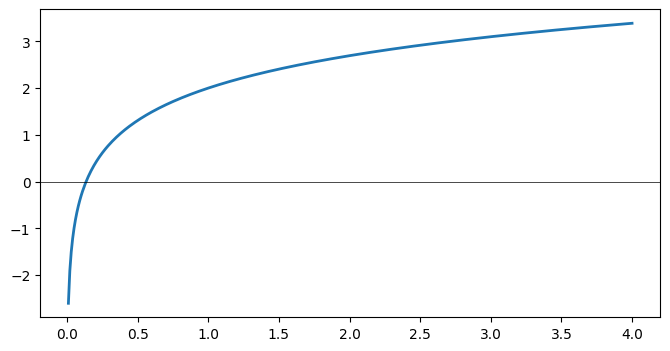

In [ ]:
# Divergent case

def f_0(x):
    return np.log(x) * x + x

def f(x):
    return np.log(x) + 2

def df(x):
    return 1/ x


def newton_raphson(x0, n_iter=5):
    iterates = [x0]
    for _ in range(n_iter):
        x0 = x0 - f(x0) / df(x0)
        iterates.append(x0)
    return iterates

# Initial points for the new polynomial
initial_points = [0.01, 1, 3]



# Plot the function and iterates for each initial point
x = np.linspace(0,4, 400)
y = f(x)
z = f_0(x)

plt.figure(figsize=(8, 4))
plt.plot(x, z, label='$f_0(x) $', linewidth=2)
plt.axhline(0, color='black', lw=0.5)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$f(x) $', linewidth=2)
plt.axhline(0, color='black', lw=0.5)



trajectories = []

for x0 in initial_points:
    iterates = newton_raphson(x0)
    trajectories.append(iterates)



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = [f"x0 = {x0:.9f}" for x0 in initial_points]

# Print the DataFrame
print(df)

## Observations:

- Newton Raphson for finding root of $F(x) = 0$ can either **diverge**, or **cycle**, or converge.
- If there are multiple roots (thus $F$ is not monotone), Newton Raphson is sensitive to intiialization. In this case, **chaotic behaviors** appear.
- Even when $F$ is monotone, Newton Raphson might diverge because the update direction is too large. We can remedy this by adding a stepsize.

When using a stepsize, we update by
$$
x_{k+1}= x_k - \alpha \cdot d_k,
$$
where $d_k$ is the update direction given by Newton Raphson. The stepsize $\alpha_k$ can be chosen by backtracking line search, that is, find the largest $\alpha$ such that $\| F(x_{k+1}) \| \leq \| F(x_k)\|$.

We can also just try a constant stepsize version, which is simpler to implement.

In [ ]:
# backtracking line search
# this implementation only consider univaraite case

def norm_based_line_search_newton_raphson(f, df, x0, n_iter=5, alpha_start=1, decrease_factor=0.5, tol=1e-6):
    iterates = [x0]
    for _ in range(n_iter):
        alpha = alpha_start
        delta = -f(x0) / df(x0)

        while np.abs(f(x0 + alpha * delta)) >= np.abs(f(x0)) and alpha > tol:
            alpha *= decrease_factor
        x0 += alpha * delta
        iterates.append(x0)
    return iterates

# constant stepsize, alpha = 1 is the vanilla version
def constant_stepsize_newton_raphson(f, df, x0, n_iter=5, alpha=1.0):
    iterates = [x0]
    for _ in range(n_iter):
        update_step = -f(x0) / df(x0)
        x0 += alpha * update_step
        iterates.append(x0)
    return iterates





### Let's go back to the previous examples.

**cycle**:
$F(x) = x^3 - 2x + 2$, initialized from $x_0 = 0$.

In [ ]:
def f(x):
    return x**3 - 2*x + 2

def df(x):
    return 3 * x**2 - 2

x_0 = 0



iterates1 = constant_stepsize_newton_raphson(f, df, x_0, n_iter=20, alpha = 1)
values1 = [f(x) for x in iterates1]
iterates2 = constant_stepsize_newton_raphson(f, df, x_0, n_iter=20, alpha = 0.5)
values2 = [f(x) for x in iterates2]
iterates3 = norm_based_line_search_newton_raphson(f, df, x_0, n_iter=20, alpha_start=1, decrease_factor=0.5)
values3 = [f(x) for x in iterates3]
trajectories=[iterates1, values1,  iterates2,values2, iterates3, values3]



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = ["Standard Newton Raphson", "Values", "Small Stepsize","Values", "Line Search", "Values"]

# Print the DataFrame
print(df)


    Standard Newton Raphson  Values  Small Stepsize    Values  Line Search  \
0                       0.0     2.0        0.000000  2.000000     0.000000   
1                       1.0     1.0        0.500000  1.125000     1.000000   
2                       0.0     2.0        0.950000  0.957375     0.750000   
3                       1.0     1.0        0.273410  1.473618     0.842187   
4                       0.0     2.0        0.688340  0.949463     0.814291   
5                       1.0     1.0        1.508877  2.417523     0.816868   
6                       0.0     2.0        1.258623  1.476579     0.816391   
7                       1.0     1.0        0.990388  0.990664     0.818064   
8                       0.0     2.0        0.464895  1.170687     0.816255   
9                       1.0     1.0        0.897963  0.928135     0.816991   
10                      0.0     2.0       -0.209563  2.409923     0.816274   
11                      1.0     1.0        0.435405  1.211733   

**Divergent Casee**: $F(x) = x^{1/3}$

In [ ]:
def f(x):
    if x<=0:
       return 1e10
    return x ** (1/3)

def df(x):
    if x<=0:
       return 1
    return 1/3 * x ** (-2/3)


x_0 = 2

iterates1 = constant_stepsize_newton_raphson(f, df, x_0, n_iter=20, alpha = 1)
values1 = [f(x) for x in iterates1]
iterates2 = constant_stepsize_newton_raphson(f, df, x_0, n_iter=20, alpha = 0.3)
values2 = [f(x) for x in iterates2]
iterates3 = norm_based_line_search_newton_raphson(f, df, x_0, n_iter=20, alpha_start=1, decrease_factor=0.3)
values3 = [f(x) for x in iterates3]
trajectories=[iterates1, values1,  iterates2,values2, iterates3, values3]



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = ["Standard Newton Raphson", "Values", "Small Stepsize","Values", "Line Search", "Values"]


# Print the DataFrame
print(df)


    Standard Newton Raphson        Values  Small Stepsize        Values  \
0              2.000000e+00  1.259921e+00    2.000000e+00  1.259921e+00   
1             -4.000000e+00  1.000000e+10    2.000000e-01  5.848035e-01   
2             -1.000000e+10  1.000000e+10    2.000000e-02  2.714418e-01   
3             -2.000000e+10  1.000000e+10    2.000000e-03  1.259921e-01   
4             -3.000000e+10  1.000000e+10    2.000000e-04  5.848035e-02   
5             -4.000000e+10  1.000000e+10    2.000000e-05  2.714418e-02   
6             -5.000000e+10  1.000000e+10    2.000000e-06  1.259921e-02   
7             -6.000000e+10  1.000000e+10    2.000000e-07  5.848035e-03   
8             -7.000000e+10  1.000000e+10    2.000000e-08  2.714418e-03   
9             -8.000000e+10  1.000000e+10    2.000000e-09  1.259921e-03   
10            -9.000000e+10  1.000000e+10    2.000000e-10  5.848035e-04   
11            -1.000000e+11  1.000000e+10    2.000000e-11  2.714418e-04   
12            -1.100000e+

**Divergent Casee** $F(x) = \log (x) + 2$.

In [ ]:
def f(x):
    if x<=0:
       return 1e10
    return np.log(x) + 2

def df(x):
    if x <=0:
        return 1
    return 1/ x


x_0 = 3

iterates1 = constant_stepsize_newton_raphson(f, df, x_0, n_iter=20, alpha = 1)
values1 = [f(x) for x in iterates1]
iterates2 = constant_stepsize_newton_raphson(f, df, x_0, n_iter=20, alpha = 0.3)
values2 = [f(x) for x in iterates2]
iterates3 = norm_based_line_search_newton_raphson(f, df, x_0, n_iter=20, alpha_start=1, decrease_factor=0.3)
values3 = [f(x) for x in iterates3]
trajectories=[iterates1, values1,  iterates2,values2, iterates3, values3]



# Convert the list of lists into a pandas DataFrame for nicer formatting
df = pd.DataFrame(trajectories).T  # Transpose to have each trajectory as a column

# Optionally, name the columns to reflect the initial points
df.columns = ["Standard Newton Raphson", "Values", "Small Stepsize","Values", "Line Search", "Values"]

# Print the DataFrame
print(df)


    Standard Newton Raphson        Values  Small Stepsize    Values  \
0              3.000000e+00  3.098612e+00        3.000000  3.098612   
1             -6.295837e+00  1.000000e+10        0.211249  0.445282   
2             -1.000000e+10  1.000000e+10        0.183029  0.301891   
3             -2.000000e+10  1.000000e+10        0.166453  0.206957   
4             -3.000000e+10  1.000000e+10        0.156118  0.142859   
5             -4.000000e+10  1.000000e+10        0.149427  0.099056   
6             -5.000000e+10  1.000000e+10        0.144987  0.068888   
7             -6.000000e+10  1.000000e+10        0.141991  0.048005   
8             -7.000000e+10  1.000000e+10        0.139946  0.033499   
9             -8.000000e+10  1.000000e+10        0.138539  0.023398   
10            -9.000000e+10  1.000000e+10        0.137567  0.016354   
11            -1.000000e+11  1.000000e+10        0.136892  0.011436   
12            -1.100000e+11  1.000000e+10        0.136422  0.007999   
13    

## Convergence Behaviors of Newton's method

Since Newton's method for minimizing $f$ is equivalent to Newton Raphson for finding the root of $\nabla f$, similar behaviors also appears in Newton's Method.

$\nabla f$ has multiple solutions means (i) $f$ is nonconvex and it has multiple stationary points.
Thus, we conclude that when
- the objective is nonconvex, even when Newton's method converges, **the stationary point it converges to is sensitive to initialization.**
- it is also possible for Newton's method to cycle,
- even when the objective function is convex, it is possible that newton's method does not converge because the newton increment is too large. We can remedy this by adding a stepsize.



Recall that the example of the polynomial $F(x) = x^3 - 2 x^2 - 11 x + 12$. The three roots are $-3,1,4$. We initialize from five different points that are quite close.
$x_0 \in \{ 2.352875270,2.352841720, 2.352837350,  2.352836327, 2.352836323 \} $. These numbers are listed in a descending order. Newton Raphson is sensitive to the initalization and finds the three roots.

$F$ is the gradient of $f(x) = 1/4 \cdot  x^4 - 2/3 \cdot x^3 - 11/2 \cdot x^2 + 12 x$.
Note that $x = 1$ is a local maximum of $f$ and it's found by Newton's method.


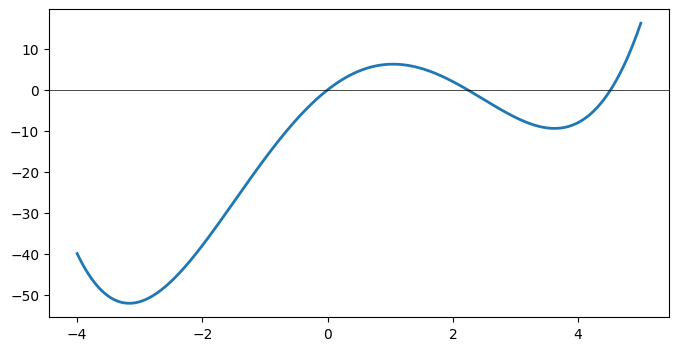

In [ ]:

# Define the function, its derivative, and the Newton-Raphson iteration function for the new polynomial
def f(x):
    return 1/4 * x**4 - 2/4 * x**3 - 11/2 * x**2 + 12* x



# Plot the function and iterates for each initial point
x_poly = np.linspace(-4, 5, 400)
y_poly = f(x_poly)

plt.figure(figsize=(8, 4))
plt.plot(x_poly, y_poly, label='$f(x)$', linewidth=2)
plt.axhline(0, color='black', lw=0.5)

## Convergence Theory of Newton's Method

Newton's method is a cornerstone of numerical optimization, offering a fast convergence rate under suitable conditions. For unconstrained optimization problems, where the objective is to minimize a function $f: \mathbb{R}^n \rightarrow \mathbb{R}$, the method's convergence properties are closely tied to the characteristics of $f$. Specifically, for functions that are strongly convex and have smooth gradients, Newton's method exhibits local quadratic convergence, provided that the Hessian of the function is Lipschitz continuous.

### Assumptions for Convergence
Before delving into the convergence phases of Newton's method, we outline the key assumptions:


- **Strong Convexity:** The function $f$ is strongly convex on the domain of interest, implying there exists a constant $m > 0$ such that for all $x, y \in \mathbb{R}^n$,
    $$
    f(y) \geq f(x) + \nabla f(x)^\top (y - x) + \frac{m}{2} \|y - x\|^2.
    $$
- **Smoothness:** The gradient of the function $f$ is Lipschitz continuous with constant $M > 0$, meaning that for all $x, y \in \mathbb{R}^n$,
 $$
    \|\nabla f(y) - \nabla f(x)\| \leq M \|y - x\|.
$$
    
- **Lipschitz Continuous Hessian:** The Hessian matrix of \(f\), denoted by $\nabla^2 f$, is Lipschitz continuous, indicating bounded changes in the curvature of $f$.


###**Convergence Theory**
Under these conditions, Newton's method converges in two distinct phases:


 - **Phase I (Global Convergence):** Initially, with a stepsize $\alpha = \frac{m}{M}$, Newton's method converges linearly to a neighborhood of the minimizer. This phase ensures that the iterates are moving towards the vicinity of the optimal solution, albeit without exploiting the full potential speed of convergence.
    
- **Phase II (Local Quadratic Convergence):** Once within a certain neighborhood of the minimizer, setting the stepsize $\alpha = 1$ enables quadratic convergence. In this phase, the distance to the minimizer decreases quadratically with each iteration, showcasing the efficiency of Newton's method when close to the solution.


The transition from linear to quadratic convergence underlines the effectiveness of Newton's method in minimizing strongly convex and smooth functions. The method's rapid convergence, especially in the vicinity of the minimizer, makes it a powerful tool in optimization.



### Experiments


We will examine the convergence of newton's method on a few functions.

- **Implement Newton's Method**: We implement newton's method with a constant stepsize.
  

- **Plot Function Values vs. Iterations**: We plot $f(x_k) - p^*$ versus $k$.


- **Demonstrate Local Quadratic Convergence** We plot $\log \log (f(x_k) - p^*) $ versus $k$.
   


In [ ]:
import numpy as np
import autograd.numpy as anp  # Use autograd's numpy wrapper
from autograd import grad, hessian
import matplotlib.pyplot as plt

def newton_method(f, x_init, stepsize=1.0, n_iter=5):
    # Get the gradient and Hessian functions using autograd
    grad_f = grad(f)
    hess_f = hessian(f)

    x = x_init
    iterates = [x]
    function_values = [f(x)]
    check_optimality = False  # Initialize optimality check

    for _ in range(n_iter):
        # Compute gradient and Hessian at current x
        g = grad_f(x)
        H = hess_f(x)

        # Compute the Newton's update step
        # Use np.linalg.solve to solve for the step delta: H*delta = -g
        try:
            delta = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            print("Hessian is singular or nearly singular; Newton's method may not be applicable.")
            break

        # Update x with the stepsize
        x = x + stepsize * delta
        iterates.append(x)
        function_values.append(f(x))

    # Check the optimality condition at the last iterate
    final_gradient_norm = anp.linalg.norm(grad_f(x))
    if final_gradient_norm < 1e-8:
        check_optimality = True

    return iterates, function_values, check_optimality




def grad_descent(f, x_init, stepsize=.1, n_iter=50):
    # Get the gradient functions using autograd
    grad_f = grad(f)

    x = x_init
    iterates = [x]
    function_values = [f(x)]
    check_optimality = False  # Initialize optimality check

    for _ in range(n_iter):
        # Compute gradient and Hessian at current x
        g = grad_f(x)

        # Update x with the stepsize
        x = x - stepsize * g
        iterates.append(x)
        function_values.append(f(x))

    # Check the optimality condition at the last iterate
    final_gradient_norm = anp.linalg.norm(grad_f(x))
    if final_gradient_norm < 1e-8:
        check_optimality = True

    return iterates, function_values, check_optimality





def plot_function_values(function_values, start=0, end=None):
    if end is None:
        end = len(function_values)

    iterations = range(start, end)
    values_to_plot = function_values[start:end]

    plt.figure(figsize=(8, 6))
    plt.plot(iterations, values_to_plot, marker='o')
    plt.title('Function Values vs. Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Function Value')
    plt.grid(True)
    plt.show()


def plot_double_log_convergence(function_values, start=0, end=None):
    if end is None:
        end = len(function_values)
    p_star = min(function_values)  # Assuming p* is the minimum value found
    # Ensure f(x_k) - p* is positive; add a small constant if necessary to avoid log(0)
    fk_minus_p_star = [np.log(max(val - p_star, 1e-10)) for val in function_values[start:end]]

    iterations = np.arange(start, end)

    plt.figure(figsize=(8, 6))
    # print(fk_minus_p_star)
    # print(np.log(fk_minus_p_star))
    # Applying np.log to already log-transformed values
    plt.plot(iterations, np.log(fk_minus_p_star), marker='o')
    plt.title('Log of Log of $f(x_k) - p^*$ vs. Iterations')
    plt.xlabel('Iteration ($k$)')
    plt.ylabel('Log(Log($f(x_k) - p^*$))')
    plt.grid(True)
    plt.show()


#### Function 1:
$f(x_1, x_2) = \exp(x_1 + 3 x_2 - 0.1) + \exp(x_1 - 3 x_2 - 0.1) + \exp( - x_1 - 0.1).$

The global minimizer is not reached
Final iterate: [-0.34561919  0.00063628], final function value: 2.559270195788552
Iteration 0: x = [1. 2.], f(x) = 992.6136834352898
Iteration 1: x = [1.25904331 1.81365452], f(x) = 735.3709617024614
Iteration 2: x = [1.45282538 1.64906668], f(x) = 544.8248860373782
Iteration 3: x = [1.54774839 1.51743896], f(x) = 403.6924573943339
Iteration 4: x = [1.55833952 1.4139316 ], f(x) = 299.1598263499837
Iteration 5: x = [1.51941442 1.32694262], f(x) = 221.73527837600025
Iteration 6: x = [1.45389498 1.24883691], f(x) = 164.39127861109438
Iteration 7: x = [1.37382907 1.17560716], f(x) = 121.92362377880326
Iteration 8: x = [1.28557578 1.10514682], f(x) = 90.4776905550814
Iteration 9: x = [1.19263049 1.03631042], f(x) = 67.19825375009746
Iteration 10: x = [1.09698901 0.96846196], f(x) = 49.97033462923463
Iteration 11: x = [0.99983248 0.90125129], f(x) = 37.22730287047243
Iteration 12: x = [0.901893   0.83449895], f(x) = 27.808741124226724
Iteration 13: x = [0.

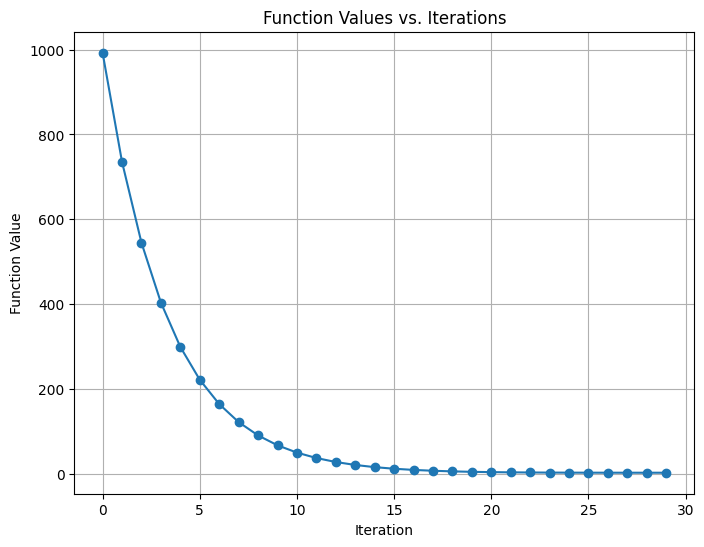

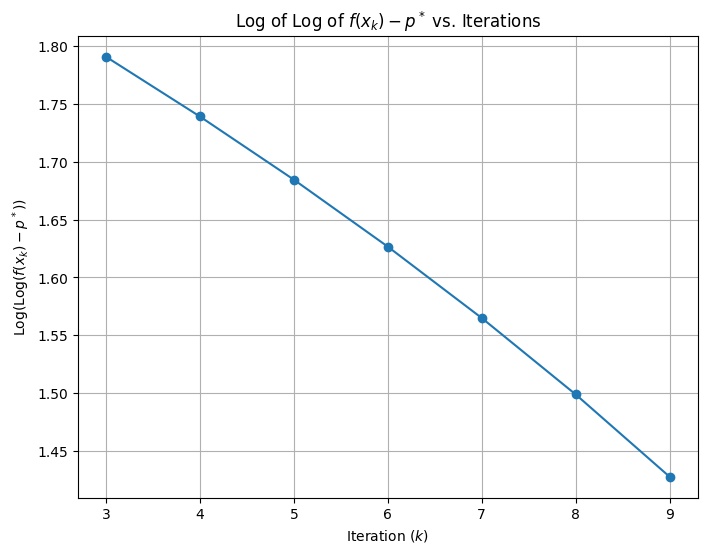

In [ ]:
def f(x):
    return anp.exp(x[0] + 3*x[1] - 0.1) + anp.exp(x[0] - 3*x[1] - 0.1) + anp.exp(-x[0] - 0.1)

x_init = np.array([1.0, 2.0])


# Run Newton's method
iterates, function_values, check_optimality = newton_method(f, x_init, n_iter=40, stepsize=0.3)

# Print the final iterate and function value
final_iterate = iterates[-1]
final_value = function_values[-1]
if check_optimality:
    print("Newton's method finds the global minimizer")
else:
    print("The global minimizer is not reached")

print(f"Final iterate: {final_iterate}, final function value: {final_value}")

# Print results
for i, (iterate, function_value) in enumerate(zip(iterates, function_values)):
    print(f"Iteration {i}: x = {iterate}, f(x) = {function_value}")

plot_function_values(function_values, start = 0, end = 30)

plot_double_log_convergence(function_values, start = 3, end = 10)



#### Function 2: Logistic Regression


The logistic loss function, used in logistic regression for binary classification tasks, is defined as:

\begin{equation}
L(\beta) = - \sum_{i=1}^{n} \left[ y_i \log(\sigma(x_i^\top \beta)) + (1 - y_i) \log(1 - \sigma(x_i^\top \beta)) \right]
\end{equation}

where
- $n$ is the number of observations,
- $y_i$ is the binary outcome for the $i$-th observation,
- $x_i$ is the feature vector for the $i$-th observation,
- $\beta$ is the parameter vector,
- $\sigma(z) = \frac{1}{1 + \exp(-z)}$ is the logistic function.



In [ ]:

def simulate_logistic_data(n, d):
    # Generate covariate matrix X
    X = np.random.randn(n, d)

    # Generate true parameter vector beta_true
    beta_true = np.random.randn(d)

    # Compute linear combination X beta
    linear_combination = X @ beta_true

    # Compute probabilities using the logistic function
    probabilities = 1 / (1 + np.exp(-linear_combination))

    # Generate binary outcomes y
    y = np.random.binomial(1, probabilities)

    return X, y, beta_true


def make_logistic_loss(X, y):
    def logistic_loss(beta):
        linear_combination = X @ beta
        probabilities = 1 / (1 + anp.exp(-linear_combination))  # Use anp.exp here
        loss = -anp.sum(y * anp.log(probabilities) + (1 - y) * anp.log(1 - probabilities))
        return loss
    return logistic_loss



The global minimizer is not reached
Final iterate: [ 0.76138003  1.13739563 -0.68613474  0.15555174  0.34755479  0.54459028
  0.53015043  1.5409096  -1.5158954   2.19811261], final function value: 28.615407696718307
The L2-norm error is 1.1284107577994928

Iteration 0: f(x) = 92.95547269952061
Iteration 1: f(x) = 54.49027341972261
Iteration 2: f(x) = 46.44612472008381
Iteration 3: f(x) = 41.507101836475826
Iteration 4: f(x) = 38.126867238885
Iteration 5: f(x) = 35.68945412465772
Iteration 6: f(x) = 33.882559945626625
Iteration 7: f(x) = 32.524061562469356
Iteration 8: f(x) = 31.497195679116313
Iteration 9: f(x) = 30.721662300453442
Iteration 10: f(x) = 30.139142531328538
Iteration 11: f(x) = 29.70547480522774
Iteration 12: f(x) = 29.386246326625454
Iteration 13: f(x) = 29.154237956882245
Iteration 14: f(x) = 28.98787211629007
Iteration 15: f(x) = 28.870175747255335
Iteration 16: f(x) = 28.787990215428135
Iteration 17: f(x) = 28.731299627688035
Iteration 18: f(x) = 28.69263081466578
Ite

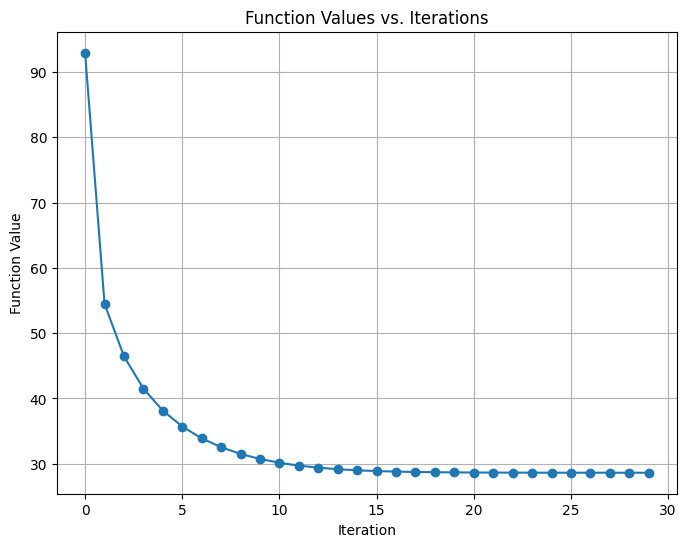

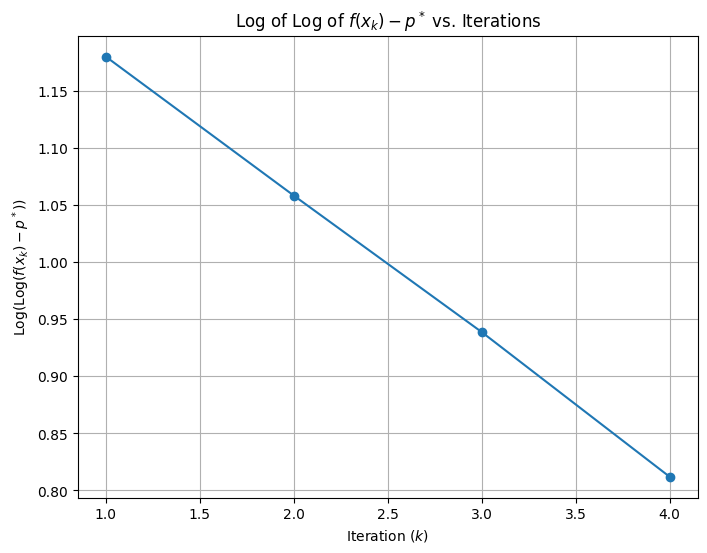

In [ ]:
# Assuming simulate_logistic_data function exists
n, d = 100, 10  # For example, 100 observations and 10 features
X, y, beta_true = simulate_logistic_data(n, d)

# Create logistic loss function specific to X and y
f = make_logistic_loss(X, y)

# Initial guess for beta
x_init = np.ones(d,)  # Adjust dimensions as necessary

# Run Newton's method
iterates, function_values, check_optimality = newton_method(f, x_init, n_iter=50, stepsize=0.2)

# Print results
if check_optimality:
    print("Newton's method finds the global minimizer")
else:
    print("The global minimizer is not reached")

print(f"Final iterate: {iterates[-1]}, final function value: {function_values[-1]}")

estiamted_param = iterates[-1]
print(f"The L2-norm error is {np.linalg.norm(estiamted_param - beta_true)}\n")


# Print results
for i, (iterate, function_value) in enumerate(zip(iterates, function_values)):
    print(f"Iteration {i}: f(x) = {function_value}")

plot_function_values(function_values, start = 0, end = 30)

plot_double_log_convergence(function_values, start = 1, end = 5)


#### Compare gradient descent with Newton Method



Newton's method finds the global minimizer
The global minimizer is not reached by GD
Iteration 0: Newton f(x) = 92.95547269952061, GD f(x) = 92.95547269952061
Iteration 1: Newton f(x) = 43.32139923342974, GD f(x) = 48.32508251523049
Iteration 2: Newton f(x) = 38.25132551770393, GD f(x) = 32.973851549025404
Iteration 3: Newton f(x) = 34.97966992005424, GD f(x) = 30.477252055232213
Iteration 4: Newton f(x) = 32.78139800519041, GD f(x) = 29.78539518207086
Iteration 5: Newton f(x) = 31.29093462209312, GD f(x) = 29.471223097538257
Iteration 6: Newton f(x) = 30.289559979002078, GD f(x) = 29.27965050987158
Iteration 7: Newton f(x) = 29.631496502595155, GD f(x) = 29.170843535983167
Iteration 8: Newton f(x) = 29.212379621055575, GD f(x) = 29.13240744110575
Iteration 9: Newton f(x) = 28.955040473495952, GD f(x) = 29.166356922678776
Iteration 10: Newton f(x) = 28.802938189171268, GD f(x) = 29.266189541228563
Iteration 11: Newton f(x) = 28.716257366506813, GD f(x) = 29.455872829640178
Iteration 12

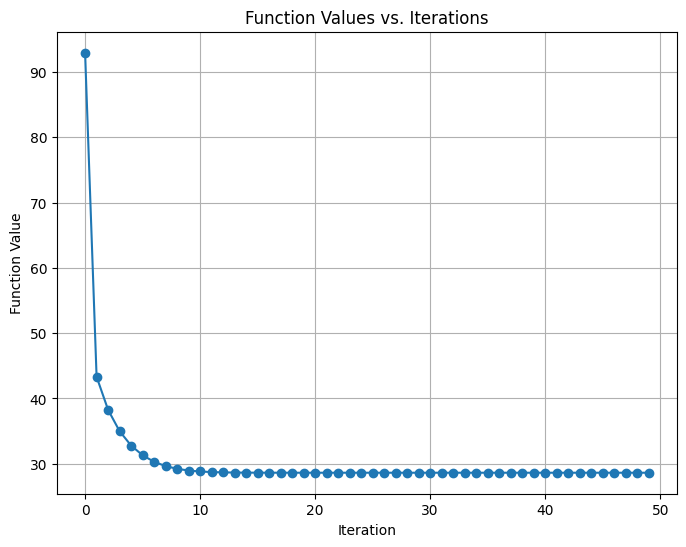

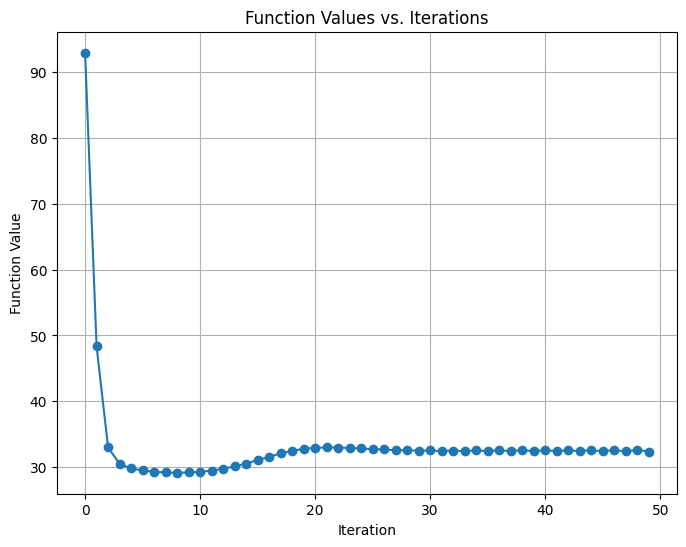

In [ ]:
f = make_logistic_loss(X, y)

# Initial guess for beta
x_init = np.ones(d,)  # Adjust dimensions as necessary

# Run Newton's method
f = make_logistic_loss(X, y)

# Initial guess for beta
x_init = np.ones(d,)  # Adjust dimensions as necessary

# Run Newton's method
iterates_nt, function_values_nt, check_optimality_nt = newton_method(f, x_init, n_iter=100, stepsize=0.3)

iterates_gd, function_values_gd, check_optimality_gd = grad_descent(f, x_init, n_iter =100, stepsize=0.15)



# Print results
if check_optimality_nt:
    print("Newton's method finds the global minimizer")
else:
    print("The global minimizer is not reached by newton's methods")

if check_optimality_gd:
    print("Gradient descent finds the global minimizer")
else:
    print("The global minimizer is not reached by GD")

for i, (iterate, function_value_nt, function_value_gd) in enumerate(zip(iterates_nt, function_values_nt, function_values_gd)):
    print(f"Iteration {i}: Newton f(x) = {function_value_nt}, GD f(x) = {function_value_gd}")

plot_function_values(function_values_nt, start = 0, end = 50)

plot_function_values(function_values_gd, start = 0, end = 50)


### Function 3

$f(x) = x^\top x -  \sum_{i=1}^m \log (b_i - a_i^\top x)$ where $x \in \mathbb{R}^n$.

Newton's method finds the global minimizer
Final iterate: [ 0.76138003  1.13739563 -0.68613474  0.15555174  0.34755479  0.54459028
  0.53015043  1.5409096  -1.5158954   2.19811261], final function value: 28.615407696718307

The global minimizer is not reached by GD
Iteration 0: Newton f(x) = 5.175110288287574, GD f(x) = 5.175110288287574
Iteration 1: Newton f(x) = 1.9120354918580462, GD f(x) = -1.7963144173017482
Iteration 2: Newton f(x) = -1.169991732439605, GD f(x) = -4.606534167997539
Iteration 3: Newton f(x) = -3.9351631905611284, GD f(x) = -5.7179753559548585
Iteration 4: Newton f(x) = -6.239101748875027, GD f(x) = -6.5122873342231955
Iteration 5: Newton f(x) = -7.994434957091842, GD f(x) = -7.1222473240326165
Iteration 6: Newton f(x) = -9.21315175896451, GD f(x) = -7.6101202766832365
Iteration 7: Newton f(x) = -9.988270794174715, GD f(x) = -8.010911919850757
Iteration 8: Newton f(x) = -10.442851331990163, GD f(x) = -8.346471087716274
Iteration 9: Newton f(x) = -10.689286293932074

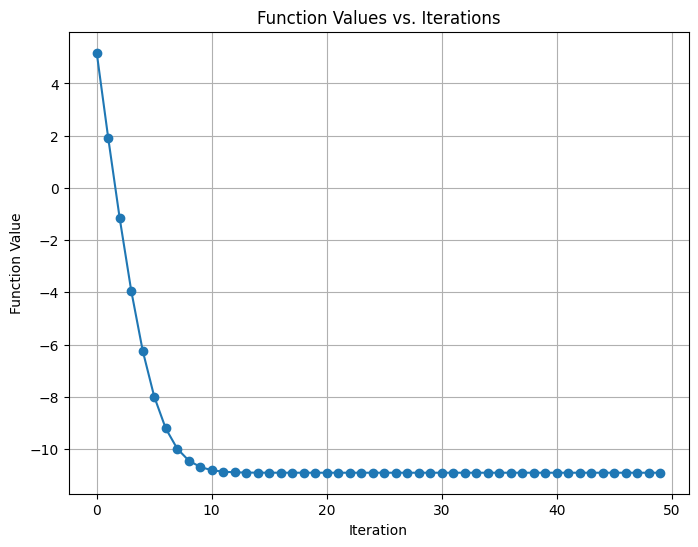

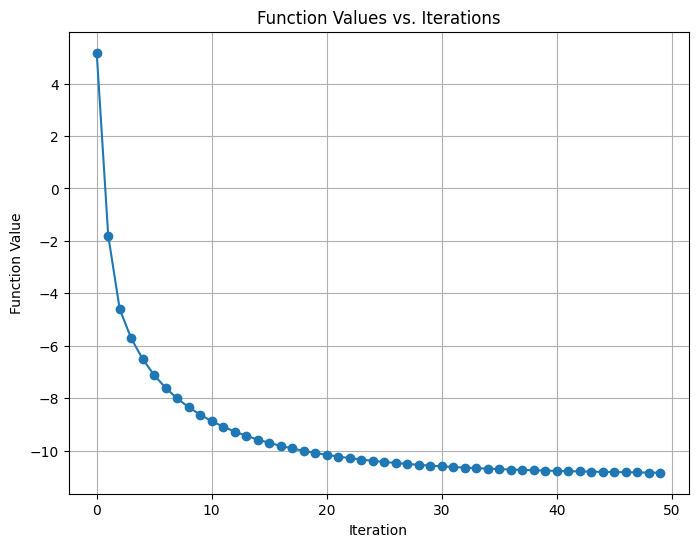

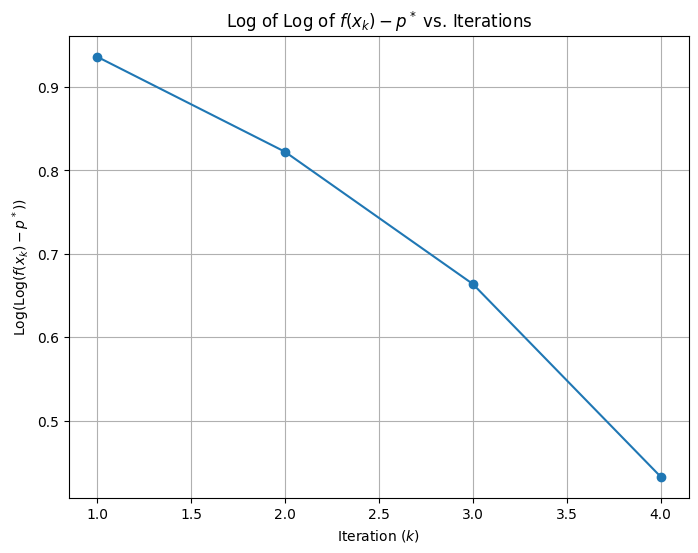

In [ ]:
def generate_function(m, n):
    A = np.random.randn(m, n)  # Random matrix A of size m by n
    b = np.random.rand(m)  # Random vector b of size m

    def f(x):
        # Ensure x is an autograd numpy array for compatibility
        x = anp.array(x)
        # Compute the function sum(log(b_i - A[i,:] @ x))
        return - anp.sum(anp.log(b - A @ x)) + x @ x

    return f

# Example of generating the function and using it
m, n = 10, 50  # Example sizes
f = generate_function(m, n)

# Example usage with autograd
x_init = np.zeros(n)  # Initial guess for x


# Run Newton's method
iterates_nt, function_values_nt, check_optimality_nt = newton_method(f, x_init, n_iter = 50, stepsize=0.4)

iterates_gd, function_values_gd, check_optimality_gd = grad_descent(f, x_init, n_iter = 50, stepsize=0.01)



# Print results
if check_optimality_nt:
    print("Newton's method finds the global minimizer")
else:
    print("The global minimizer is not reached by newton's methods")


print(f"Final iterate: {iterates[-1]}, final function value: {function_values[-1]}\n")



if check_optimality_gd:
    print("Gradient descent finds the global minimizer")
else:
    print("The global minimizer is not reached by GD")

for i, (iterate, function_value_nt, function_value_gd) in enumerate(zip(iterates_nt, function_values_nt, function_values_gd)):
    print(f"Iteration {i}: Newton f(x) = {function_value_nt}, GD f(x) = {function_value_gd}")

plot_function_values(function_values_nt, start = 0, end = 50)

plot_function_values(function_values_gd, start = 0, end = 50)


plot_double_log_convergence(function_values_nt, start = 1, end = 5)


## Summary

This notebook explored **Newton's method** from multiple angles:

| Topic | Key idea |
|---|---|
| **Newton for minimization** | Update $x^{k+1} = x^k - [f''(x^k)]^{-1} f'(x^k)$ by minimizing the local quadratic model. |
| **Newton-Raphson for root finding** | Update $x^{k+1} = x^k - F(x^k)/F'(x^k)$ by following the tangent line to the $x$-axis. |
| **Sensitivity to initialization** | Nearby starting points can converge to entirely different roots -- the basin-of-attraction boundaries form **Newton fractals**. |
| **Cycling and divergence** | Without safeguards, iterates can cycle (period 2 or higher) or diverge when the Newton step overshoots. |
| **Domain violations** | A full Newton step may leave the natural domain of $f$ (e.g., $x > 0$ for $\log x$). |
| **Damped Newton / line search** | Replacing the unit step with $x^{k+1} = x^k - \alpha_k\, d^k$ and choosing $\alpha_k$ by backtracking restores convergence in many pathological cases. |
| **Convergence theory** | Under strong convexity ($m$), smoothness ($M$), and Lipschitz Hessian, damped Newton converges linearly (Phase I) then quadratically (Phase II) once $\alpha = 1$ is accepted. |
| **Newton vs. gradient descent** | On logistic regression and log-barrier objectives, Newton converges in far fewer iterations, at the cost of computing and inverting the Hessian each step. |